# Kenya's Climate: Basic Exploration

## Step 1: Importing the Data

In this step, we load the required datasets using Pandas and NumPy and perform an initial inspection of the Kenya climate dataset.


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## Step 2: Cleaning the Data

This step involves handling missing values, correcting data types, removing inconsistencies, and preparing the dataset for analysis.


In [3]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


In [4]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 0


In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct
})

missing_df

,missing,percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [7]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

124


In [8]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.ffill()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


Export cleaned data

In [9]:
df.to_csv("../data/kenya_clean.csv", index=False)

## Step 3: Exploration of the Data

We analyze Kenya’s climate data to identify patterns, trends, and seasonal behavior across the years.

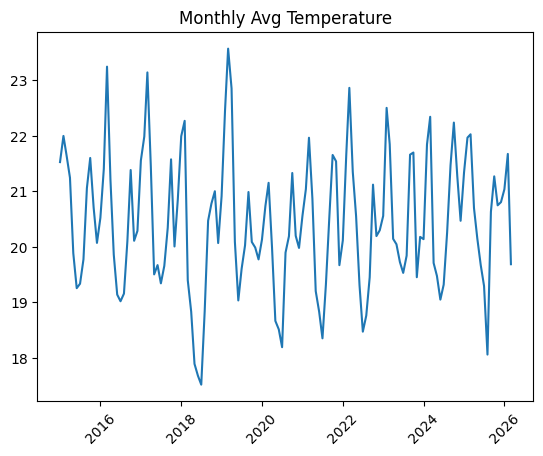

In [10]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["date"], monthly_temp["T2M"])
plt.title("Monthly Avg Temperature")
plt.xticks(rotation=45)
plt.show()

## Interpretation 1: Monthly Average Temperature (2015–2026)

The analysis of Kenya’s monthly average temperature from 2015 to 2026 shows noticeable annual fluctuations rather than a steady trend.

The **lowest temperature values occur around 2018**, dropping to below approximately 18°C, indicating a relatively cooler phase in the dataset. In contrast, the **highest temperatures also appear around late 2018 and early 2019**, showing a sharp intra-year variation where both extreme low and high temperatures occur within a short time span.

Compared to Ethiopia, Kenya shows a **less extreme range of temperature variation**, with generally higher minimum temperatures and less severe drops. This suggests a more moderate temperature profile overall.

The overall trend shows a pattern of **decrease → sharp increase → decrease → increase → final decline toward 2026**, indicating strong variability rather than a stable directional trend.

In summary, Kenya’s temperature pattern is characterized by:
- Moderate temperature extremes compared to Ethiopia  
- A significant dip around 2018  
- Sharp short-term fluctuations within and across years  
- No consistent long-term warming or cooling trend, but repeated cyclical changes  

<Figure size 640x480 with 0 Axes>

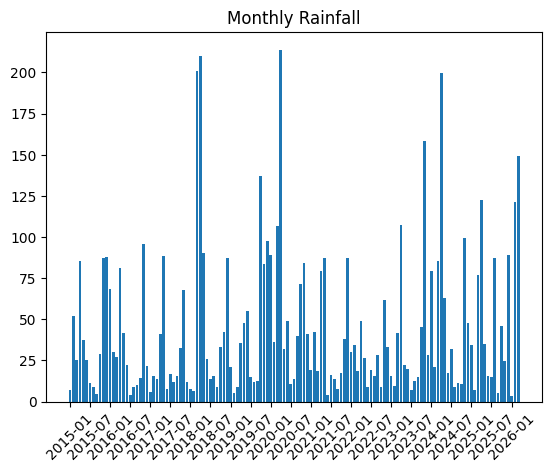

In [11]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
plt.figure()
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

# Create a label column for the x-axis
monthly_rain["label"] = monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(monthly_rain["label"], monthly_rain["PRECTOTCORR"])

step = 6
plt.xticks(
    ticks=range(0, len(monthly_rain), step),
    labels=monthly_rain["label"][::step],
    rotation=45
)

plt.title("Monthly Rainfall")
plt.show()

## Interpretation 2: Monthly Rainfall Patterns (2015–2026)

The monthly rainfall data for Kenya shows strong variability with distinct peak periods and significant differences between minimum and maximum values.

The dataset reveals **major rainfall peaks around 2017–2018**, with two distinct peaks occurring during this period rather than a single maximum value. This suggests a highly active rainfall phase with multiple intense precipitation events within the same year.

Additional rainfall peaks are also observed around **2020 and again in 2023–2024**, indicating that Kenya experiences intermittent high-rainfall cycles rather than a steady pattern.

Overall, the rainfall distribution shows a **very large gap between minimum and maximum values**, highlighting strong variability in monthly precipitation.

The **lowest recorded rainfall occurs around 2025**, where values drop close to zero, suggesting an unusually dry period compared to the rest of the dataset.

In summary, Kenya’s rainfall pattern is characterized by:
- Multiple peak rainfall periods (2017–2018, 2020, 2023–2024)  
- High variability between dry and wet months  
- Occasional extreme rainfall spikes rather than consistent patterns  
- A notably dry phase around 2025  

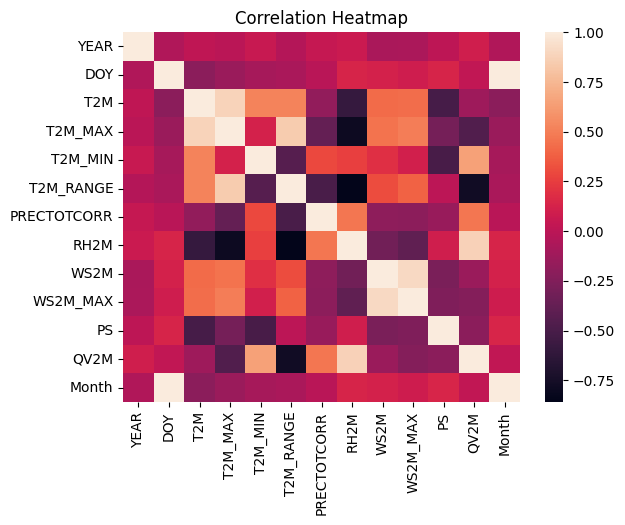

In [12]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

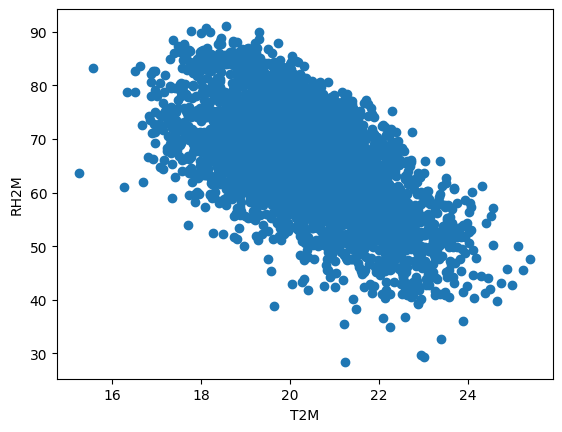

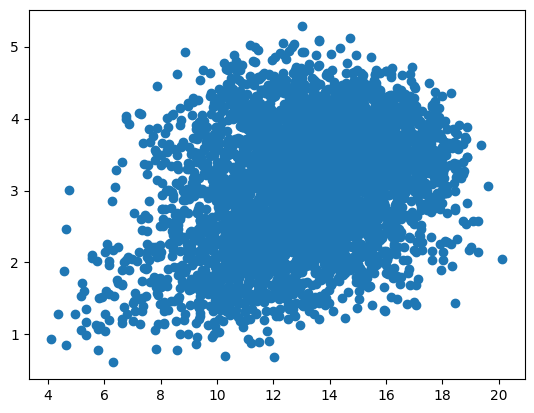

In [13]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

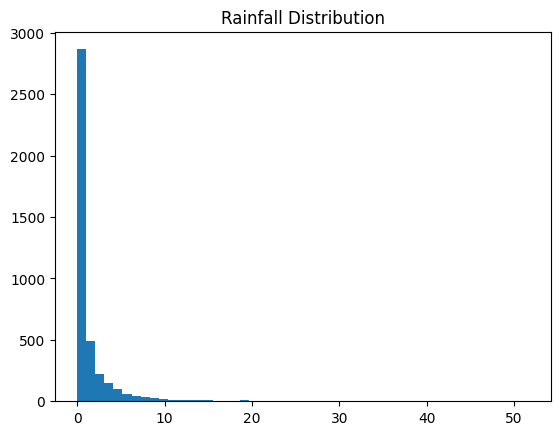

In [14]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.title("Rainfall Distribution")
plt.show()

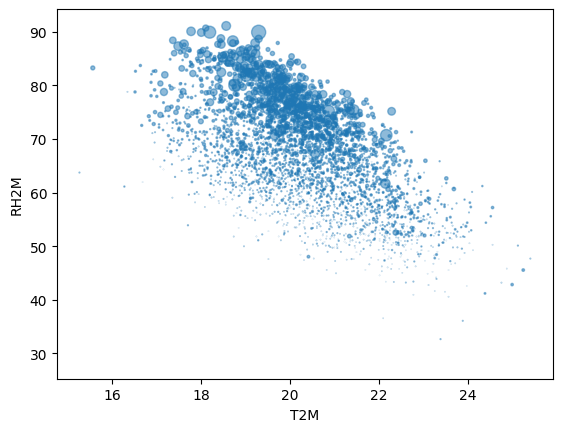

In [15]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()